# Lubrification non newtonienne (loi puissance)

Ce notebook illustre la modélisation analytique et numérique des profils de vitesse pour des écoulements en film mince, en mécanique des fluides non newtoniennes (fluide loi puissance).

Trois cas sont étudiés :
1. Poiseuille avec gradient de pression imposé.
2. Poiseuille avec débit imposé.
3. Couette–Poiseuille avec débit imposé.
4. Passage au fin avec débit imposé.

## 1. Import des bibliothèques et paramètres globaux

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

## 2. Paramètres physiques et domaine de calcul

In [13]:
h = 1.0
K = 150000.0
n = 0.2
Ny = 500
y = np.linspace(0, h, Ny)

## Fonction utilitaire pour la loi puissance

In [14]:
def power_law_prefactor(G, K, n):
    return (n / (n + 1)) * (abs(G)**(1/n - 1) * G) / (K**(1/n))

## 3. Cas 1 : Poiseuille avec gradient de pression imposé

In [15]:
def velocity_poiseuille_G(y, h, G, K, n):
    A = power_law_prefactor(G, K, n)
    p = (n + 1) / n
    return A * (np.abs(y - h / 2)**p - (h / 2)**p )

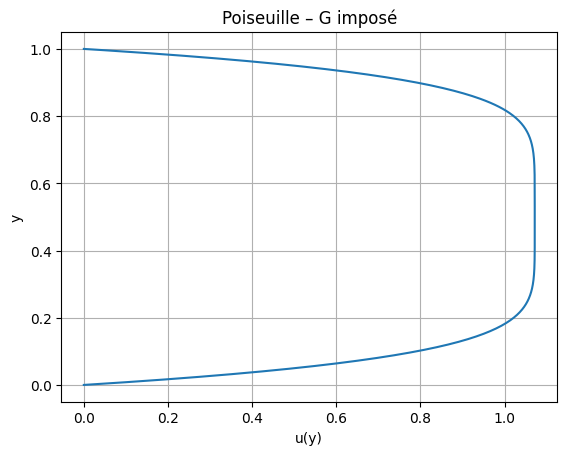

In [16]:
G = -5e5
u1 = velocity_poiseuille_G(y, h, G, K, n)

plt.figure()
plt.plot(u1, y)
plt.xlabel('u(y)')
plt.ylabel('y')
plt.title('Poiseuille – G imposé')
plt.grid()
plt.show()

## 4. Cas 2 : Poiseuille avec débit imposé - Débit analytique et inversion pour Poiseuille

In [17]:
def flowrate_poiseuille(G, h, K, n):
    return -(2*n)/(2*n+1) * abs(G)**(1/n-1) * G * (h/2)**((2*n+1)/n) / (K**(1/n))

def gradient_from_Q_poiseuille(Q, h, K, n):
    C = -(2*n)/(2*n+1) * (h/2)**((2*n+1)/n) / (K**(1/n))
    return -np.sign(Q) * (abs(Q)/abs(C))**n

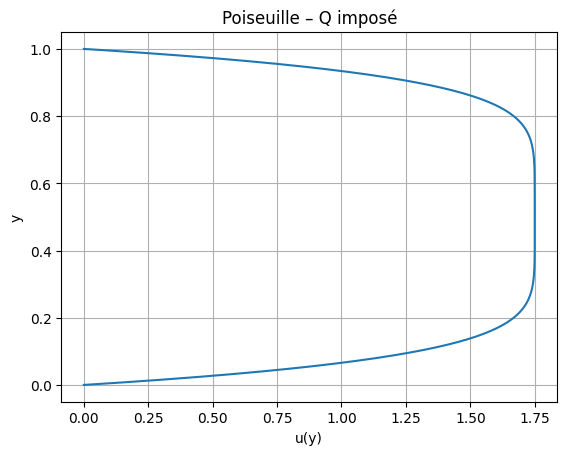

In [18]:
Q = 1.5
G2 = gradient_from_Q_poiseuille(Q, h, K, n)
u2 = velocity_poiseuille_G(y, h, G2, K, n)

plt.figure()
plt.plot(u2, y)
plt.xlabel('u(y)')
plt.ylabel('y')
plt.title('Poiseuille – Q imposé')
plt.grid()
plt.show()

## 5. Cas 3 : configuration Couette–Poiseuille avec débit imposé

### Remarque numérique importante (Couette–Poiseuille, loi puissance)

Pour des fluides fortement pseudo-plastiques (n ≪ 1) et des indices
de consistance élevés (K ≫ 1), la résolution directe en G = dp/dx
est très mal conditionnée.

On introduit la variable intermédiaire :

    S = A(G) = (n/(n+1)) |G|^{1/n-1} G / K^{1/n}

et on résout le problème non linéaire en (C, S), ce qui rend le système
numériquement stable. Le gradient de pression G est reconstruit a posteriori.


In [19]:
# ============================================================
# ÉTAPE 1 — RÉSOLUTION DE C POUR UN S DONNÉ
# ============================================================

def solve_C_for_S(S):
    """
    Résout :
    S*(|h+C|^p - |C|^p) = Uh - U0
    """

    def F(C):
        return S*(abs(h + C)**p - abs(C)**p) - (Uh - U0)

    # Encadrement robuste
    Cmax = 10*h
    return brentq(F, -Cmax, Cmax)

# ============================================================
# ÉTAPE 2 — CALCUL DU DÉBIT POUR UN S DONNÉ
# ============================================================

def compute_Q_for_S(S):
    C = solve_C_for_S(S)

    # constante additive
    C2 = U0 - S*abs(C)**p

    # profil de vitesse
    u = S*abs(y + C)**p + C2

    # débit
    return np.trapz(u, y)

# ============================================================
# ÉTAPE 3 — TIR SUR S (DICHOTOMIE / BRENT)
# ============================================================

def find_S_for_Q(Q_target):
    """
    Trouve S tel que Q(S) = Q_target
    """

    # Débit Couette pur
    Q_couette = 0.5*(U0 + Uh)*h

    if abs(Q_target - Q_couette) < 1e-12:
        return 0.0

    # Encadrement initial
    Smin, Smax = -1.0, 1.0

    # Élargir jusqu'à encadrement valide
    while (compute_Q_for_S(Smin) - Q_target)*(compute_Q_for_S(Smax) - Q_target) > 0:
        Smin *= 2
        Smax *= 2

    return brentq(lambda S: compute_Q_for_S(S) - Q_target, Smin, Smax)

Solution trouvée :
S = -26.27391195014965
C = -0.5986816777722288
u(0) ; u(h)= 0.10000000000000009 1.2000000000000006
Débit = 1.2000000000000002


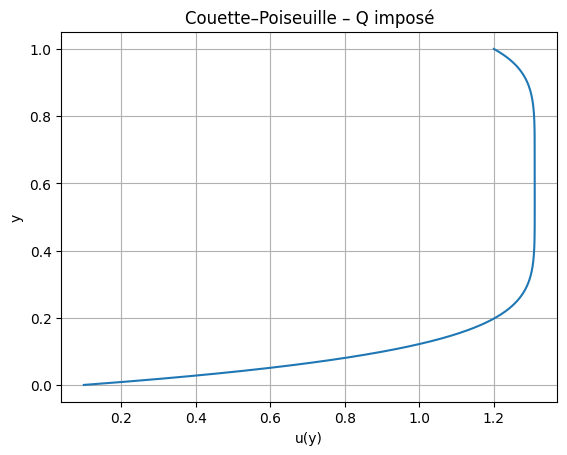

In [20]:
U0 = 0.1   # vitesse paroi y=0
Uh = 1.2  # vitesse paroi y=h

Q_target = 1.2   # débit imposé (≠ Couette pur)

p = (n + 1) / n

S_sol = find_S_for_Q(Q_target)
C_sol = solve_C_for_S(S_sol)

# Profil final
C2_sol = U0 - S_sol*abs(C_sol)**p
u_sol = S_sol*abs(y + C_sol)**p + C2_sol

print("Solution trouvée :")
print("S =", S_sol)
print("C =", C_sol)
print("u(0) ; u(h)=", u_sol[0], u_sol[-1])
print("Débit =", np.trapz(u_sol, y))

plt.figure()
plt.plot(u_sol, y)
plt.xlabel('u(y)')
plt.ylabel('y')
plt.title('Couette–Poiseuille – Q imposé')
plt.grid()
plt.show()

## 5. Cas 4 : passage au fin avec débit imposé

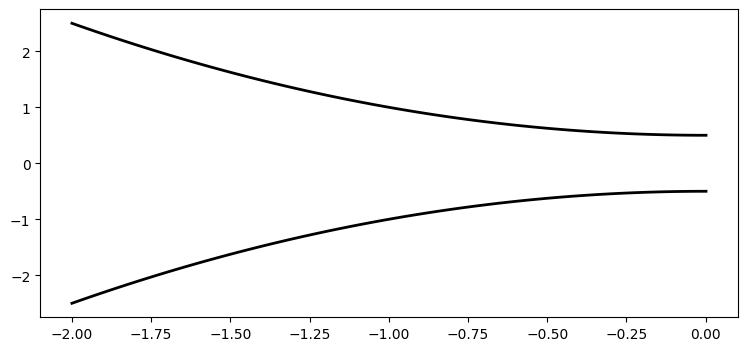

In [43]:

# ============================================================
# PARAMÈTRES PHYSIQUES ET GEOMETRIQUES
# ============================================================

friction=1.1
U_lower = 0.5
U_upper = U_lower*friction

# Débit imposé (différent du Couette pur)
Q_couette_0 = 0.5 * (U_lower + U_upper) * h
Q_cyl = 1.2 * Q_couette_0

p = (n + 1) / n

# Géométrie cylindres (approchée parabolique)
R1 = 1.0
R2 = 1.0
h0 = 1.0

L = 2.0
Nx = 80
x_cyl = np.linspace(-L, 0.001, Nx)

h_cyl = h0 + 0.5 * x_cyl**2 * (1/R1 + 1/R2)

plt.figure(figsize=(9, 4))
plt.plot(x_cyl, -h_cyl/2, 'k', lw=2)
plt.plot(x_cyl,  h_cyl/2, 'k', lw=2)


In [44]:
# ============================================================
# RÉSOLUTION DE C POUR UN S DONNÉ (PROBLÈME COUETTE)
# ============================================================

def solve_C_for_S(S, h, U0, Uh):
    def F(C):
        return S * (abs(h + C)**p - abs(C)**p) - (Uh - U0)
    return brentq(F, -10*h, 10*h)

# ============================================================
# CALCUL DU DÉBIT POUR UN S DONNÉ
# ============================================================

def compute_Q_for_S(S, h, U0, Uh):
    C = solve_C_for_S(S, h, U0, Uh)
    C2 = U0 - S * abs(C)**p
    y = np.linspace(0, h, Ny)
    u = S * abs(y + C)**p + C2
    return np.trapz(u, y)

# ============================================================
# MÉTHODE DE TIR SUR S (PAR BRENT)
# ============================================================

def find_S_for_Q(h, U0, Uh, Q_target):
    Q_couette = 0.5 * (U0 + Uh) * h
    if abs(Q_target - Q_couette) < 1e-10:
        return 0.0

    Smin, Smax = -1.0, 1.0
    while (compute_Q_for_S(Smin, h, U0, Uh) - Q_target) * \
          (compute_Q_for_S(Smax, h, U0, Uh) - Q_target) > 0:
        Smin *= 2
        Smax *= 2

    return brentq(lambda S: compute_Q_for_S(S, h, U0, Uh) - Q_target,
                  Smin, Smax)


def cyl_velocity_profile(y, h, C, S, n, U_lower, U_upper):
    """
    Profil de vitesse Couette–Poiseuille (loi puissance)
    en repère physique y ∈ [0, h].

    Paramètres
    ----------
    y : array
        Coordonnée verticale dans [0, h]
    h : float
        Épaisseur du film
    C, S : floats
        Paramètres issus de la méthode de tir
    n : float
        Indice loi puissance
    U_lower, U_upper : floats
        Vitesses imposées aux parois y=0 et y=h

    Retour
    ------
    u : array
        Profil de vitesse u(y)
    """
    p = (n + 1) / n
    C2 = U_lower - S * abs(C)**p
    return S * abs(y + C)**p + C2

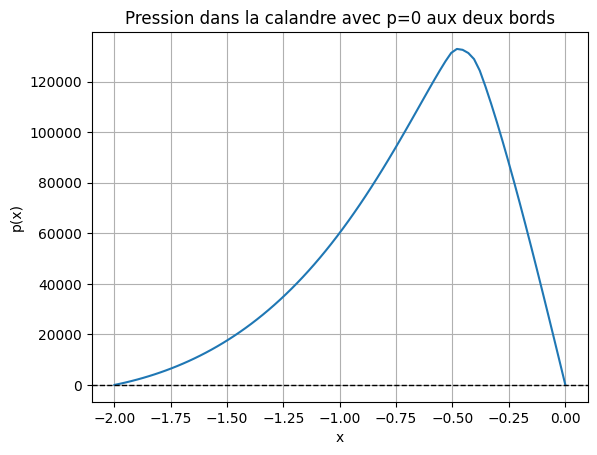

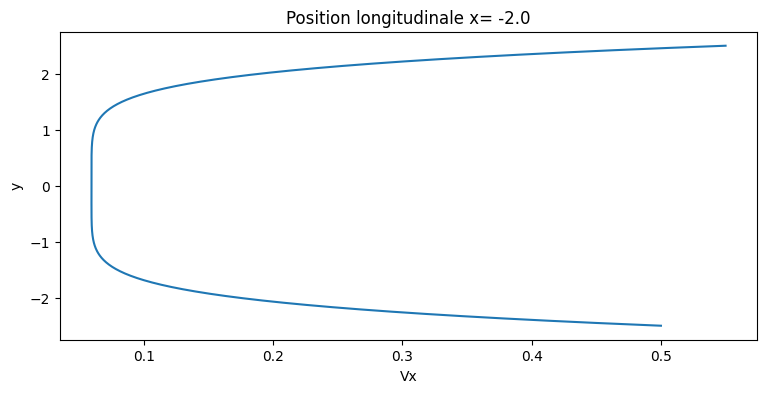

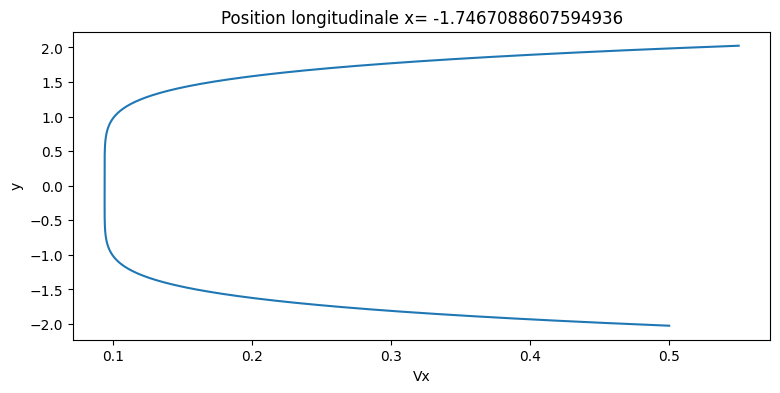

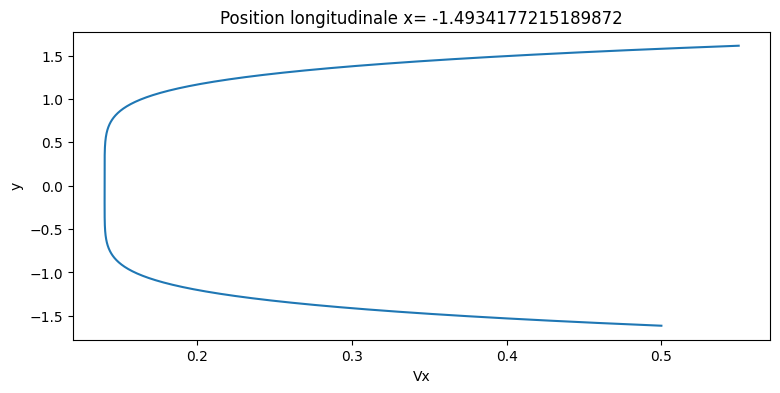

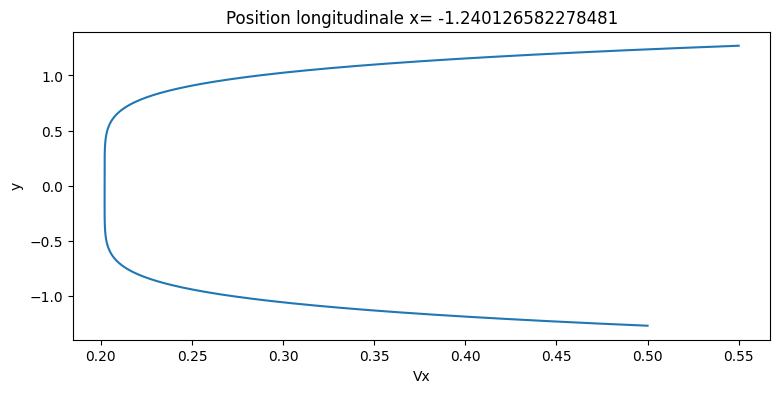

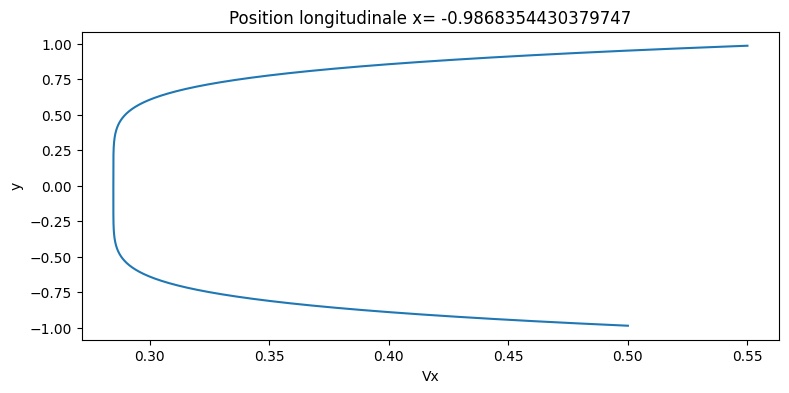

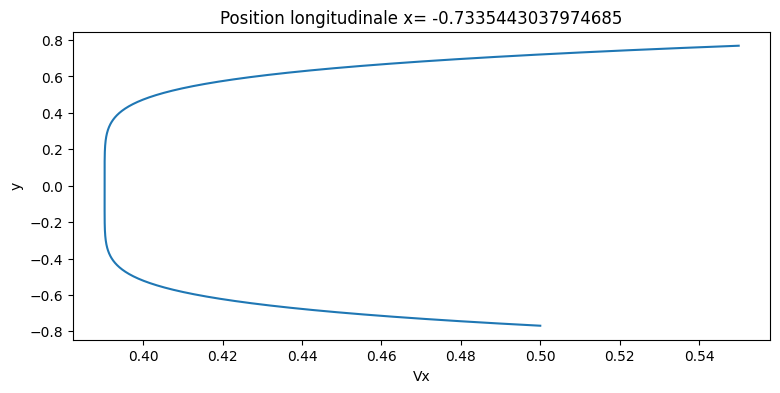

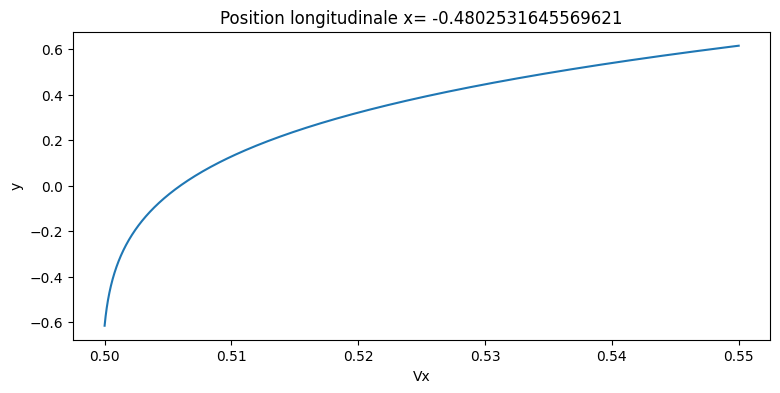

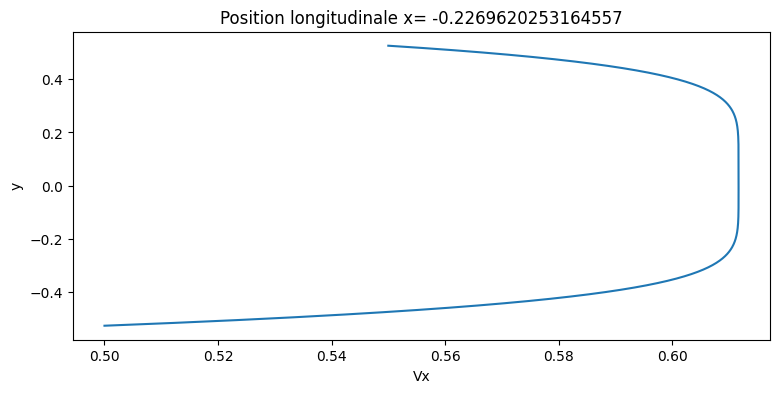

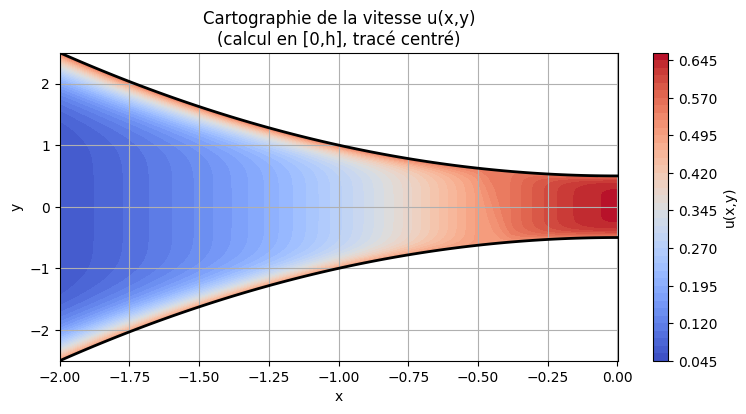

In [45]:
# ============================================================
# RÉSOLUTION LOCALE À CHAQUE x
# ============================================================

C_x = np.zeros(Nx)
S_x = np.zeros(Nx)

for i in range(Nx):
    hi = h_cyl[i]
    S_x[i] = find_S_for_Q(hi, U_lower, U_upper, Q_cyl)
    C_x[i] = solve_C_for_S(S_x[i], hi, U_lower, U_upper)


# ============================================================
# CALCUL DE dp/dx ET INTÉGRATION DE LA PRESSION
# ============================================================

# Gradient de pression
G_x = np.sign(S_x) * ((n+1)/n * np.abs(S_x) * K**(1/n))**n

# Intégration brute
p_raw = np.zeros_like(x_cyl)
for i in range(1, len(x_cyl)):
    p_raw[i] = p_raw[i-1] + 0.5*(G_x[i] + G_x[i-1])*(x_cyl[i] - x_cyl[i-1])

# Correction affine pour imposer p=0 aux deux bords
xL, xR = x_cyl[0], x_cyl[-1]
a = (p_raw[-1] - p_raw[0]) / (xR - xL)
b = p_raw[0] - a*xL
p_x = p_raw - (a*x_cyl + b)

# ============================================================
# VISUALISATION PRESSION
# ============================================================
plt.figure()
plt.plot(x_cyl, p_x)
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel("x")
plt.ylabel("p(x)")
plt.title("Pression dans la calandre avec p=0 aux deux bords")
plt.grid()
plt.show()

# ============================================================
# CARTOGRAPHIE u(x,y) AVEC TRICONTOURF
# (profil calculé en [0,h], tracé en [-h/2,h/2])
# ============================================================

from matplotlib.tri import Triangulation
N_plot=10

X_pts = []
Y_pts = []
U_pts = []

Ny_loc = Ny

for i in range(len(x_cyl)):
    xi = x_cyl[i]
    hi = h_cyl[i]

    # -----------------------------
    # REPÈRE PHYSIQUE [0,h]
    # -----------------------------
    y_phys = np.linspace(0.0, hi, Ny_loc)

    u_loc = cyl_velocity_profile(
        y_phys, hi,
        C_x[i], S_x[i],
        n, U_lower, U_upper
    )

    # -----------------------------
    # REPÈRE DE VISUALISATION CENTRÉ
    # -----------------------------
    y_plot = y_phys - hi/2

    if i % N_plot==0:
        plt.figure(figsize=(9, 4))
        plt.plot(u_loc,y_plot)
        plt.xlabel('Vx')
        plt.ylabel('y')
        plt.title('Position longitudinale x= ' + str(xi))

    X_pts.extend(xi * np.ones_like(y_plot))
    Y_pts.extend(y_plot)
    U_pts.extend(u_loc)

X_pts = np.array(X_pts)
Y_pts = np.array(Y_pts)
U_pts = np.array(U_pts)


# ------------------------------------------------------------
# Triangulation
# ------------------------------------------------------------
tri = Triangulation(X_pts, Y_pts)

# ------------------------------------------------------------
# Masque géométrique basé sur l'entrefer local
# ------------------------------------------------------------
mask = np.zeros(len(tri.triangles), dtype=bool)

for k, tri_idx in enumerate(tri.triangles):
    xs = X_pts[tri_idx]
    ys = Y_pts[tri_idx]

    x_c = xs.mean()
    y_c = ys.mean()

    h_loc = np.interp(x_c, x_cyl, h_cyl)

    if not (-h_loc/2 <= y_c <= h_loc/2):
        mask[k] = True

tri.set_mask(mask)

# ------------------------------------------------------------
# Visualisation
# ------------------------------------------------------------
plt.figure(figsize=(9, 4))

plt.plot(x_cyl, -h_cyl/2, 'k', lw=2)
plt.plot(x_cyl,  h_cyl/2, 'k', lw=2)

cont = plt.tricontourf(
    tri, U_pts,
    levels=50,
    cmap="coolwarm"
)

plt.colorbar(cont, label="u(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cartographie de la vitesse u(x,y)\n"
          "(calcul en [0,h], tracé centré)")

plt.grid()
plt.show()